# Proyecto - Computación Avanzada

## Estudio de caso para 4 poblaciones (2 depredadores y 2 presas)

In [1]:
from pesca_env import Pesca4D
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from stable_baselines3 import PPO
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.env_util import make_vec_env

In [2]:
"""
Orden de los datos
[Presa1, Presa2, Depredador1, Depredador2]
"""

#Factor de crecimiento de cada poblacion
r = np.array([0.9, 0.7, 0.3, 0.2])

#Factor de ruido agregado al sistema
sigma = 0.05

#Poblacion inicial de cada especie
init_B = np.array([0.4, 0.7, 0.1, 0.2])

#Factor terminated
T = 200

#Factor de mortalidad de cada especie
mort = [0.1, 0.2, 0.3, 0.02]

#Factor de arrastre para presas y cazadores
arrastre = [0.1, 0.2]

#Factor que limita el valor maximo de la poblacion depredadora
C = 1

observables = np.array([0])

#Diccionario con los parametros del env
params = { "r_crecimiento": r,
           "sigma": sigma,
           "init_B": init_B,
           "T": T,
           "mortalidad": mort,
           "C": C,
           "epsilon": 1e-5,
           "arrastre": arrastre,
           "observables": observables
}

In [7]:
def init_agent(env, model, training=False, name="pesca_4D"):
    if training == True:
        #Inicializa el modelo
        if model == "RecurrentPPO":
            agent = RecurrentPPO("MlpLstmPolicy", env, verbose=1, device="cpu")
        
            #Entrena el modelo
            agent.learn(total_timesteps=5000)
        
            #Guarda el modelo
            agent.save("RecurentPPO_" + name)

        elif model == "PPO":
            #Inicializa el modelo
            agent = PPO("MlpPolicy", env, verbose=1, device="cpu")
            
            #Entrena el modelo
            agent.learn(total_timesteps=25000)
            
            #Guarda el modelo
            agent.save("PPO_" + name)            

    else:
        if model == "RecurrentPPO":
            #Carga el modelo
            agent = RecurrentPPO.load(name, device="cpu")
            
        elif model == "PPO":
            #Carga el modelo
            agent = PPO.load(name, device="cpu")
        
    return agent

def time_evolution(env, agent, N=200):
    #Reinicia el environment
    obs, _ = env.reset()

    #Guarda la evolucion de las poblaciones
    data_B = np.zeros((N,len(obs)))
    rewards = np.zeros(N)    

    for i in range(N):
        #El agente define una accion segun la observación
        action, _ = agent.predict(obs, deterministic=True)
        action = np.array([-1])
    
        #Calcula un step del environment segun la acción
        obs, reward, terminated, truncated, _ = env.step(action)
    
        #Registra la población de cada paso
        data_B[i] = env.B.copy()
    
        #Registra los rewards de cada paso
        rewards[i] = reward
    
    return data_B, rewards

In [8]:
#Inicializa el ambiente
env = Pesca4D(params)

#Inicializa el agente
agent = init_agent(env, training=True)

data_B, rewards = time_evolution(env,agent)
print(np.shape(data_B))

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------
| time/              |     |
|    fps             | 308 |
|    iterations      | 1   |
|    time_elapsed    | 0   |
|    total_timesteps | 128 |
----------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 200          |
|    ep_rew_mean          | 62.7         |
| time/                   |              |
|    fps                  | 44           |
|    iterations           | 2            |
|    time_elapsed         | 5            |
|    total_timesteps      | 256          |
| train/                  |              |
|    approx_kl            | 6.661471e-05 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.42        |
|    explained_variance   | 0.00104      |
|    learning_rate        | 0.0003       |
|    loss      

KeyboardInterrupt: 

## Resultados: Evolución temporal de la población y del harvest

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(12, 5))

# Gráfica de Población1
axs[0,0].plot(data_B[:,0])
axs[0,0].set_xlabel("t")
axs[0,0].set_ylabel("Población Presa 1")
axs[0,0].set_title("Evolución de la Presa 1")
axs[0,0].grid(True)

# Gráfica de Población2
axs[0, 1].plot(data_B[:,1])
axs[0, 1].set_xlabel("t")
axs[0, 1].set_ylabel("Población Presa 2")
axs[0, 1].set_title("Evolución del Presa 2")
axs[0, 1].grid(True)

# Gráfica de Depredador1
axs[1, 0].plot(data_B[:,2])
axs[1, 0].set_xlabel("t")
axs[1, 0].set_ylabel("Población Depredador 1")
axs[1, 0].set_title("Evolución del Depredador 1")
axs[1, 0].grid(True)

# Gráfica de Depredador2
axs[1, 1].plot(data_B[:,3])
axs[1, 1].set_xlabel("t")
axs[1, 1].set_ylabel("Población Depredador 2")
axs[1, 1].set_title("Evolución del Depredador 2")
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

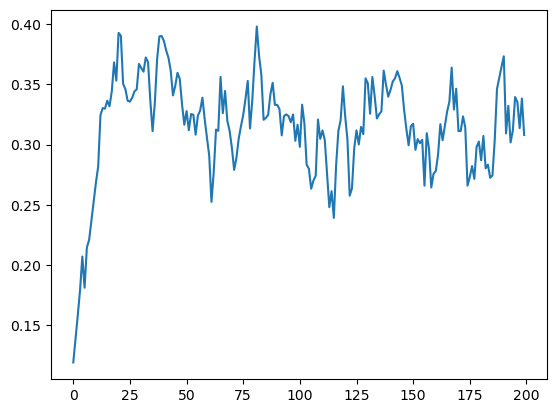

In [34]:
plt.plot(harvest)
plt.show()

## Resultados: Población (Biomasa) en función del harvest (mortalidad por pesca)

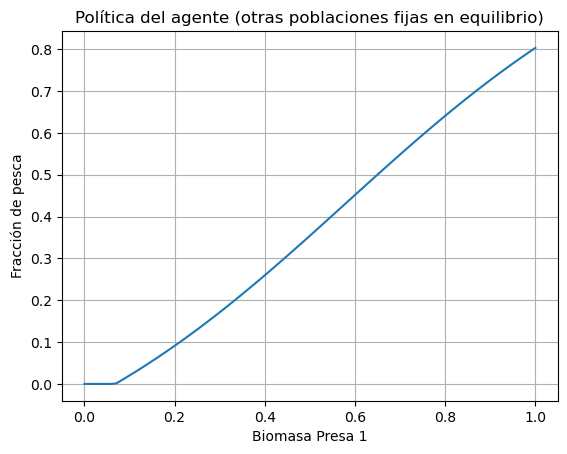

In [8]:
M = 100
biomass = np.linspace(0, 1, M)
actions = np.zeros(M)

# Valores fijos de referencia para las otras poblaciones
presa2_ref    = 0.73  # Ajusta al equilibrio que observaste
depred1_ref   = 0.80
depred2_ref   = 0.80

for i in range(M):
    obs = np.array([
        -1 + 2 * biomass[i],       # Presa1 varía
        -1 + 2 * presa2_ref,       # Presa2 fija
        -1 + 2 * depred1_ref,      # Depredador1 fijo
        -1 + 2 * depred2_ref       # Depredador2 fijo
    ], dtype=np.float32)
    
    action, _ = agent.predict(obs, deterministic=True)
    actions[i] = (action[0] + 1) / 2

plt.plot(biomass, actions)
plt.xlabel("Biomasa Presa 1")
plt.ylabel("Fracción de pesca")
plt.title("Política del agente (otras poblaciones fijas en equilibrio)")
plt.grid(True)
plt.show()

In [ ]:
#Cantidad de steps
N = 200

#Reinicia el sistema y obtiene la observación inicial
obs, _ = env.reset()

#Listas para guardar la población y el harvest
presa1 = np.zeros(N)
depredador1 = np.zeros(N)
presa2 = np.zeros(N)
depredador2 = np.zeros(N)
harvest = np.zeros(N)
reward_total = 0

for i in range(N):
    #El agente define una accion segun la observación
    action, _ = agent.predict(obs, deterministic=True)
    action = np.array([-1])

    #Calcula un step del environment segun la acción
   #obs, reward, terminated, truncated, _ = env.step(action)
    obs, reward, terminated, truncated, _ = env.step(action)

    #Registra la población de cada paso
    presa1[i] = env.unnormalize(obs[0])
    presa1[i] = env.B[0]
    presa2[i] = env.unnormalize(obs[1])
    depredador1[i] = env.unnormalize(obs[2])
    depredador2[i] = env.unnormalize(obs[3])

    #Registra los rewards de cada paso
    harvest[i] = reward

    reward_total += reward